# Model Training & Benchmarking

We'll engineer features using TF-IDF, compare a few baseline classifiers (NB, LR, SVM), and select the best one based on validation F1-score.

In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from typing import Dict, Any, List, Tuple

# Config
TRAIN_PATH = 'train.csv'
VAL_PATH = 'validation.csv'
TEST_PATH = 'test.csv'
RANDOM_STATE = 42

# Logging setup
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger(__name__)

plt.style.use('seaborn-v0_8')

In [7]:
def load_data() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load up the splits."""
    try:
        train_df = pd.read_csv(TRAIN_PATH)
        val_df = pd.read_csv(VAL_PATH)
        test_df = pd.read_csv(TEST_PATH)
        
        # Handle any NaN weirdness if it exists
        for df in [train_df, val_df, test_df]:
            df['clean_text'] = df['clean_text'].fillna('').astype(str)
            
        logger.info("Data loaded.")
        return train_df, val_df, test_df
    except FileNotFoundError as e:
        logger.error(f"Data missing: {e}")
        raise

In [8]:
def run_feature_engineering(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame) -> Tuple[Any, Any, Any, Any, Any, Any]:
    """Vectorize the text. Important: Fit ONLY on train."""
    logger.info("Vectorizing text...")
    tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
    
    X_train = tfidf.fit_transform(train_df['clean_text'])
    X_val = tfidf.transform(val_df['clean_text'])
    X_test = tfidf.transform(test_df['clean_text'])
    
    y_train = train_df['label']
    y_val = val_df['label']
    y_test = test_df['label']
    
    logger.info(f"Vocab size: {len(tfidf.vocabulary_)}")
    return X_train, X_val, X_test, y_train, y_val, y_test

In [9]:
def mask_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Visual confusion matrix plotting."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [10]:
def train_and_eval(name: str, model: Any, X_train, y_train, X_val, y_val) -> Dict[str, float]:
    """Train, predict, and log metrics."""
    logger.info(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    y_pred_val = model.predict(X_val)
    
    # We care most about the 'spam' F1 score
    f1 = f1_score(y_val, y_pred_val, pos_label='spam')
    acc = accuracy_score(y_val, y_pred_val)
    
    logger.info(f"[{name}] Val Acc: {acc:.4f} | F1 (Spam): {f1:.4f}")
    print(classification_report(y_val, y_pred_val))
    
    return {'name': name, 'model': model, 'f1': f1, 'accuracy': acc}

Data loaded.
Vectorizing text...
Vocab size: 5000
--- Starting Benchmarking ---

Training Naive Bayes...
[Naive Bayes] Val Acc: 0.9767 | F1 (Spam): 0.9051

Training Logistic Regression...
[Logistic Regression] Val Acc: 0.9632 | F1 (Spam): 0.8429

Training SVM...


              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       965
        spam       1.00      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       0.99      0.73      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



[SVM] Val Acc: 0.9848 | F1 (Spam): 0.9416

>>> Winner: SVM (Val F1: 0.9416)

--- Final Test Set Eval (SVM) ---


              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       965
        spam       0.97      0.91      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.98      0.85      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



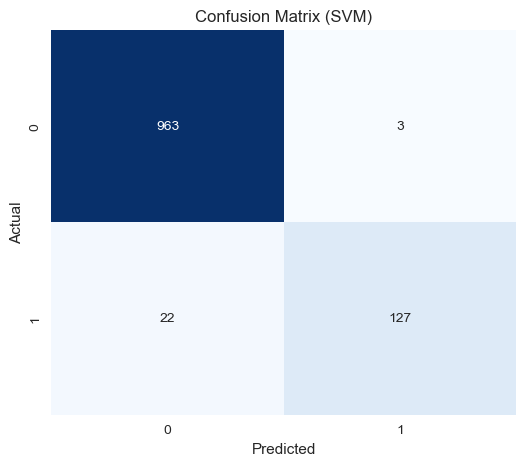

In [11]:

# Load
train_df, val_df, test_df = load_data()

# Engineer
X_train, X_val, X_test, y_train, y_val, y_test = run_feature_engineering(train_df, val_df, test_df)

# Define
models = [
    ('Naive Bayes', MultinomialNB()),
    ('Logistic Regression', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ('SVM', SVC(kernel='linear', random_state=RANDOM_STATE))
]

# Benchmark
results = []
logger.info("--- Starting Benchmarking ---")
for name, model in models:
    res = train_and_eval(name, model, X_train, y_train, X_val, y_val)
    results.append(res)
    
# Select Champion
champion = max(results, key=lambda x: x['f1'])
logger.info(f"\n>>> Winner: {champion['name']} (Val F1: {champion['f1']:.4f})")

# Final Test
logger.info(f"\n--- Final Test Set Eval ({champion['name']}) ---")
final_model = champion['model']
y_test_pred = final_model.predict(X_test)

print(classification_report(y_test, y_test_pred))
mask_confusion_matrix(y_test, y_test_pred, title=f"Confusion Matrix ({champion['name']})")